<a href="https://colab.research.google.com/github/tu25003-7491-cyber/EU_M_Math-Repository/blob/main/Hw_8_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import numpy.random as random
import scipy as sp
from pandas import Series, DataFrame
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

import sklearn

import requests
import io

In [5]:
# データを取得
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'
res = requests.get(url).content

# 取得したデータをDataFrameオブジェクトとして読み込み
mushroom = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)

# データの列にラベルを設定
mushroom.columns = ['classes', 'cap_shape', 'cap_surface', 'cap_color', 'odor', 'bruises',
                    'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color', 'stalk_shape',
                    'stalk_root', 'stalk_surface_above_ring', 'stalk_surface_below_ring',
                    'stalk_color_above_ring', 'stalk_color_below_ring', 'veil_type', 'veil_color',
                    'ring_number', 'ring_type', 'spore_print_color', 'population', 'habitat']

# 先頭5行を表示
mushroom.head()

,classes,cap_shape,cap_surface,cap_color,odor,bruises,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [6]:
print('データの形式:{}' .format(mushroom.shape))
print('欠損の数{}'.format(mushroom.isnull().sum().sum()))

データの形式:(8124, 23)
欠損の数0


In [7]:
mushroom_dummy = pd.get_dummies(mushroom[['gill_color','gill_attachment', 'odor', 'cap_color']])
mushroom_dummy.head()

,gill_color_b,gill_color_e,gill_color_g,gill_color_h,gill_color_k,gill_color_n,gill_color_o,gill_color_p,gill_color_r,gill_color_u,...,cap_color_b,cap_color_c,cap_color_e,cap_color_g,cap_color_n,cap_color_p,cap_color_r,cap_color_u,cap_color_w,cap_color_y
0,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [8]:
mushroom_dummy['flg'] = mushroom['classes'].map(lambda x: 1 if x == 'p' else 0)

In [9]:
mushroom_dummy.groupby(['cap_color_c', 'flg'])['flg'].count().unstack()

flg,0,1
cap_color_c,,
False,4176,3904
True,32,12


In [10]:
mushroom_dummy.groupby(['gill_color_b', 'flg'])['flg'].count().unstack()

flg,0,1
gill_color_b,,
False,4208.0,2188.0
True,NaN,1728.0


In [11]:
- (0.5 * np.log2(0.5) + 0.5 * np.log2(0.5))

np.float64(1.0)

In [12]:
-(0.001 * np.log2(0.001) + 0.999 * np.log2(0.999))

np.float64(0.011407757737461138)

In [13]:
def calc_entropy(p):
  return - (p * np.log2(p) + (1 - p) * np.log2(1 - p))

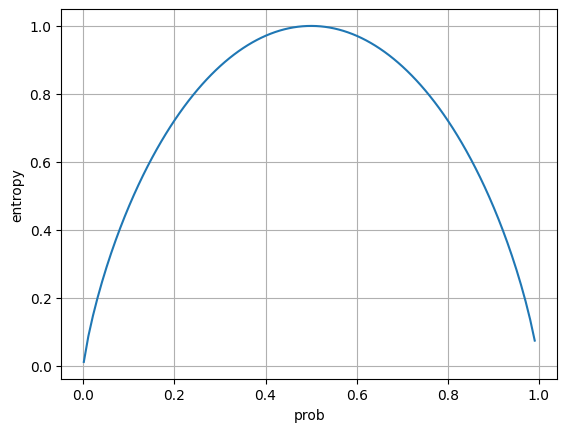

In [14]:
p = np.arange(0.001, 0.999, 0.01)
plt.plot(p, calc_entropy(p))
plt.xlabel('prob')
plt.ylabel('entropy')
plt.grid(True)

In [16]:
mushroom_dummy.groupby('flg')['flg'].count()

,flg
flg,
0,4208
1,3916


In [23]:
entropy_init = - (0.518 * np.log2(0.518) + 0.482 * np.log2(0.482))
print('毒キノコデータのエントロピー初期値:{:.3f}'.format(entropy_init))

毒キノコデータのエントロピー初期値:0.999


In [24]:
mushroom_dummy.groupby(['cap_color_c', 'flg'])[['flg']].count().unstack()

flg      
flg             0     1
cap_color_c            
False        4176  3904
True           32    12

In [25]:
# cap_colorがcでない場合のエントロピー
p1 = 4176 / (4176 + 3904)
p2 = 1 - p1
entropy_c0 = -(p1*np.log2(p1)+p2*np.log2(p2))
print('entropy_c0: {:.3f}'.format(entropy_c0))

entropy_c0: 0.999


In [26]:
# cap_colorがcである場合のエントロピー
p1 = 32/(32+12)
p2 = 1 - p1
entropy_c1 = -(p1*np.log2(p1)+p2*np.log2(p2))
print('entropy_c1: {:.3f}'.format(entropy_c1))

entropy_c1: 0.845


In [27]:
entropy_after = (4176+3904)/8124*entropy_c0 + (32+12)/8124*entropy_c1
print('データ分割後の平均エントロピー：{:.3f}'.format(entropy_after))

データ分割後の平均エントロピー：0.998


In [28]:
print('変数cap_colorの分割によって得られる情報利得：{:.3f}'.format(entropy_init - entropy_after))

変数cap_colorの分割によって得られる情報利得：0.001


In [29]:
mushroom_dummy.groupby(['gill_color_b', 'flg'])[['flg']].count().unstack()

flg        
flg                0       1
gill_color_b                
False         4208.0  2188.0
True             NaN  1728.0

In [30]:
# gill_colorがbでない場合のエントロピー
p1 = 4208/(4208+2188)
p2 = 1 - p1
entropy_b0 = -(p1*np.log2(p1) + p2*np.log2(p2))

# gill_colorがbである場合のエントロピー
p1 = 0/(0+1728)
p2 = 1 - p1
entropy_b1 = -(p2*np.log2(p2))

entropy_after = (4208+2188)/8124*entropy_b0 + (0+1728)/8124*entropy_b1
print('変数gill_colorの分割によって得られる情報利得：{:.3f}'.format(entropy_init - entropy_after))

変数gill_colorの分割によって得られる情報利得：0.269


In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# データ分割
X = mushroom_dummy.drop('flg', axis=1)
y = mushroom_dummy['flg']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# 決定木クラスの初期化と学習
model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)
model.fit(X_train, y_train)

print('正解率(train):{:.3f}'.format(model.score(X_train, y_train)))
print('正解率(test):{:.3f}'.format(model.score(X_test, y_test)))

正解率(train):0.883
正解率(test):0.894


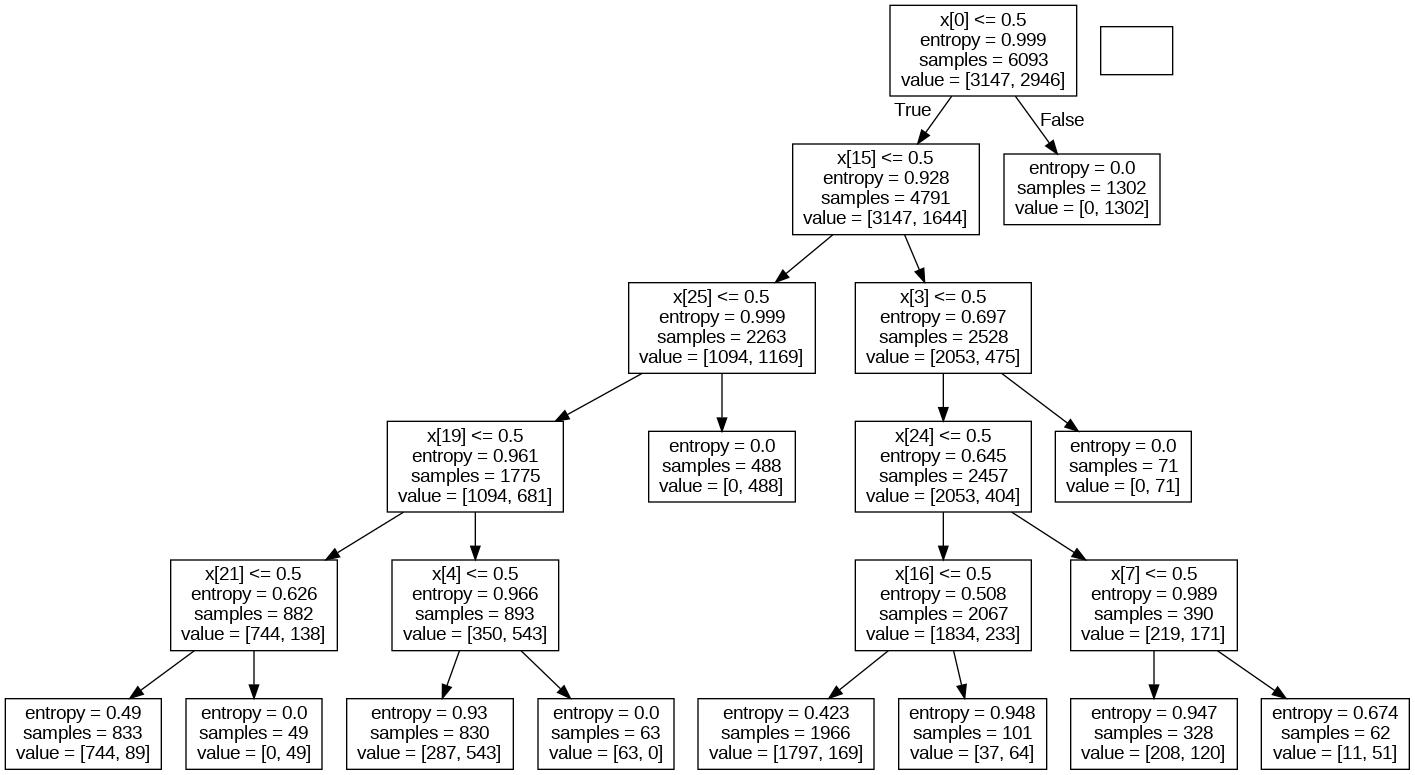

In [33]:
# 参考プログラム
# pydotplusやgraphvizをインストールする必要があります（本書ではインストールの解説は行っていません）
from sklearn import tree
import pydotplus
from io import StringIO
from IPython.display import Image

dot_data = StringIO()
tree.export_graphviz(model, out_file=dot_data)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())